In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Importe le csv des Tenracs et calcule leur nombre en avance
bd = pd.read_csv('./tenrac.csv')
nbSexes = bd['sexe'].value_counts()
print(nbSexes)

sexe
M    75233
F    24767
Name: count, dtype: int64


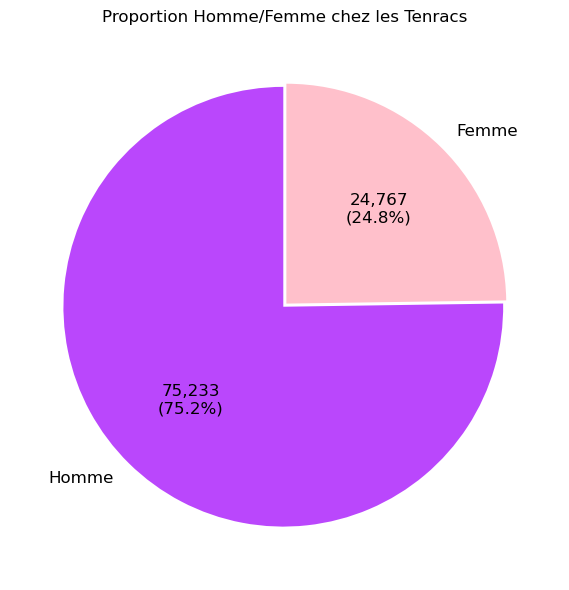

In [12]:
total = nbSexes.sum() # Calcule le total
plt.figure(figsize=(6, 6))
plt.pie(
    nbSexes,
    labels=['Homme' if x == 'M' else 'Femme' for x in nbSexes.index],
    autopct=lambda z: f"{int(round(z * total / 100)):,}" # affiche ex : "50,043"
                      f"\n({z:.1f}%)",                   # affiche ex : "(50.0%)"
    startangle=90,                                        # séparation verticale
    colors=["#ba47fc", "pink"],
    explode=[0.01, 0.01],                                 # écarte légèrement
    textprops={'fontsize': 12})

plt.title('Proportion Homme/Femme chez les Tenracs')

plt.tight_layout() # Ajuste les marges

# Commande pour télécharger le png
# plt.savefig('DiagrammeHvsF.png', dpi=1250, bbox_inches='tight')

plt.show()

In [13]:
# Importe le csv des Tenracs et calcule leur nombre décroissant en avance + fusionne les Masc avec Fem
fusion = {'AFFILIEE':'AFFILIE', 'SYMPATISANTE':'SYMPATISANT', 'ADHERANTE':'ADHERANT',
          'DAME':'CHEVALIER', 'HAUTE DAME':'GRAND CHEVALIER',
          'COMMANDERESSE':'COMMANDEUR', 'GRANDE-CROIX':'GRAND CROIX'}

nbGrade = (bd['typeGrade ']
             .str.strip() # Nettoie les espaces
             .map(lambda x: fusion.get(x, x)) # Fusionne
             .value_counts()
             .sort_values(ascending=False))

In [14]:
# Génère des couleurs uniformément depuis la palette "inferno"
couleur = plt.cm.inferno(np.linspace(0.4, 0.85, len(nbGrade)))


In [15]:
villes = bd['ville'].value_counts()
villes = villes[:50]
print(villes)

ville
Saint-Denis             124
Marseille               107
Paris                   101
Saint-Louis              93
Nice                     92
Toulouse                 88
Lyon                     87
Lille                    87
Saint-Joseph             85
Montpellier              85
Nantes                   84
Grenoble                 82
Rouen                    82
Sainte-Marie             81
Saint-Nazaire            79
Brest                    79
Reims                    78
Tours                    78
Bordeaux                 76
Angers                   75
Saint-Paul               74
Villeurbanne             74
Nimes                    74
Dijon                    74
Saint-Benoit             72
Lamentin                 72
Saint-Etienne            72
Boulogne-Billancourt     72
Mans                     72
Argenteuil               72
Creteil                  72
Rennes                   72
Havre                    71
Montreuil                71
Strasbourg               71
Orleans       

## Sur la croyance

In [16]:
#print(bd['doctrine'].count())
#print(bd['doctrine'].value_counts())

## *********
# how many believe in each thing --- modalite and counts ?
# how many of each grade believe on coryance X ?
# how many of each grade believe on each modalite de croyance?
# Correlation entre being Gradex and being croyant...?
# does it worth it to calcla droite de regresion lineaire??

### Combien de Tenracs croient en chaque croyance ?
### - Répartition des Tenracs par croyance

In [17]:
groupementDoctrine = bd.groupby("doctrine")["idTenrac"] 
# pareil a print(bd['doctrine'].value_counts()) mais on utilisant la cle primaire idtenrac
groupement_par_doctrine = groupementDoctrine.count()
print(groupement_par_doctrine)

doctrine
CONGREGATION DE L ARTICHAUT DIVIN    7066
CRUDIVEGISME                         7135
CULTE DU NAVET COSMIQUE              7332
DOGME DE LA TOMATE HERETIQUE         7127
EGLISE DU BROCOLI ETERNEL            6992
EGLISE UNIVERSELLE DU CHOU           7178
FOI CAROTICIENNE                     7151
HERBOPHOBIE SACREE                   7205
MOUVEMENT ANTI-CHLOROPHYLLE          7179
MYSTICISME RACINAIRE                 7048
ORDRE DE LA COURGETTE INTERDITE      7190
SCHISME DU RADIS NOIR                7122
SECTE DU POIREAU MAUDIT              7141
TEMPLE DE L OIGNON PRIMORDIAL        7134
Name: idTenrac, dtype: int64


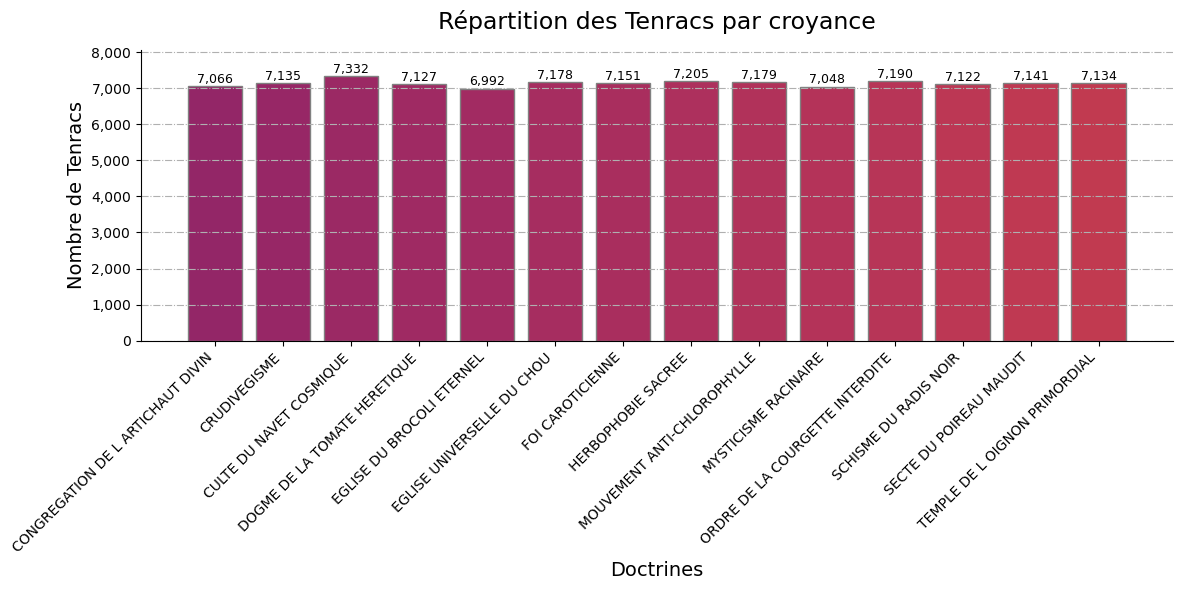

In [26]:
# Génère des couleurs uniformément depuis la palette "inferno"
couleur = plt.cm.inferno(np.linspace(0.4, 0.85))

# Crée la figure et les axes
fig, ax = plt.subplots(figsize=(12, 6))
# Dessine les barres : index = noms des grades, values = effectifs
bars = ax.bar(groupement_par_doctrine.index, groupement_par_doctrine.values, color=couleur, edgecolor='grey')

# Pour chaque barre, affiche le chiffre exact au-dessus
for bar, val in zip(bars, groupement_par_doctrine.values):
    ax.text(bar.get_x() + bar.get_width() / 2,  # centré horizontalement
            bar.get_height() + 1,                     # positionné en haut de la barre + un peu plus
            f'{val:,}',                           # séparateur milliers
            ha='center', va='bottom', fontsize=9)

ax.set_title('Répartition des Tenracs par croyance', fontsize=17, pad=15)
ax.set_xlabel('Doctrines', fontsize=14)
ax.set_ylabel('Nombre de Tenracs', fontsize=14)
# Ajoute de l'espace au-dessus de la barre la plus haute
ax.set_ylim(0, groupement_par_doctrine.max() * 1.1)

# Incline les villes à 35° alignées à droite
ax.tick_params(axis='x', rotation=45)
plt.xticks(ha='right')

# Formate l'axe Y avec des virgules
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Supprime les bordures du haut et de droite, plus joli
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Ajoute une grille en pointillés
ax.grid(axis='y', linestyle='-.')

# Ajuste les marges
plt.tight_layout()

plt.show()

In [24]:
# how many of each grade believe on coryance X ?
bd.columns = bd.columns.str.strip()
countDoctrines = pd.crosstab(bd['typeGrade'], bd['doctrine'])

#print(countDoctrines)
# Total par grade
totals = countDoctrines.sum(axis=1)

# Sort desc
doctrines_sorted = countDoctrines.loc[totals.sort_values(ascending=False).index]
print(doctrines_sorted)

doctrine          CONGREGATION DE L ARTICHAUT DIVIN  CRUDIVEGISME  \
typeGrade                                                           
SYMPATISANT                                    1124          1217   
AFFILIE                                        1134          1090   
ADHERANT                                        943           911   
CHEVALIER                                       981           952   
GRAND CHEVALIER                                 560           610   
COMMANDEUR                                      387           392   
SYMPATISANTE                                    373           363   
AFFILIEE                                        377           381   
DAME                                            325           318   
ADHERANTE                                       282           327   
GRAND CROIX                                     188           202   
HAUTE DAME                                      186           186   
COMMANDERESSE                     

In [28]:
inf7Grades = doctrines_sorted[:7] 
# Remarque: 
# inf7Grades : selon l'ordre descendant par nombre de Tenracs, ceux-ci sont le top 7 (les plus communs), 
# mais dans la hierachie de grades ils sont les grades inferieurs; pareil pour les sup7Grades (les grades superieurs)

sup7Grades = doctrines_sorted[7:]
#print(top7Grades)
#print(bottom7Grades)

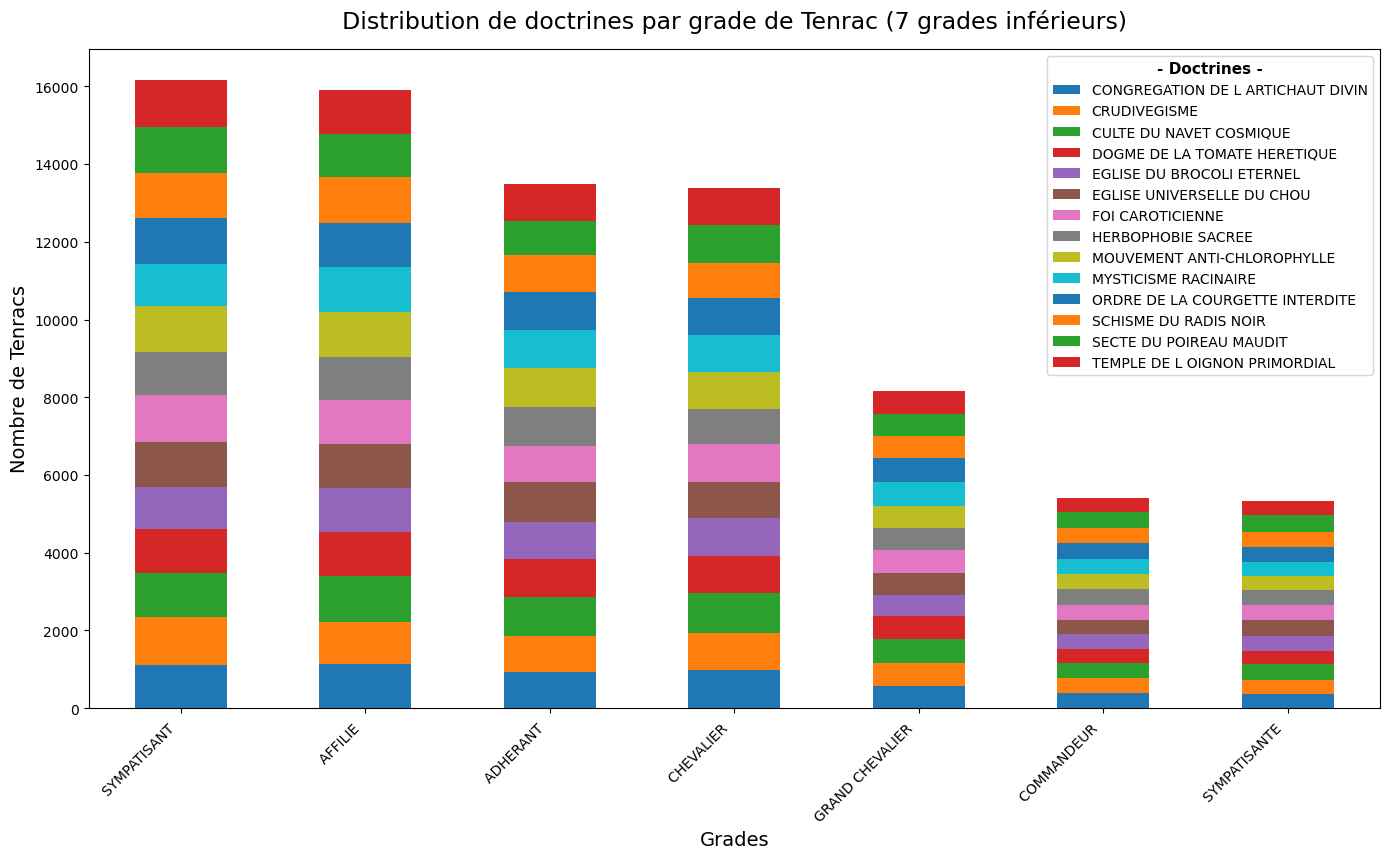

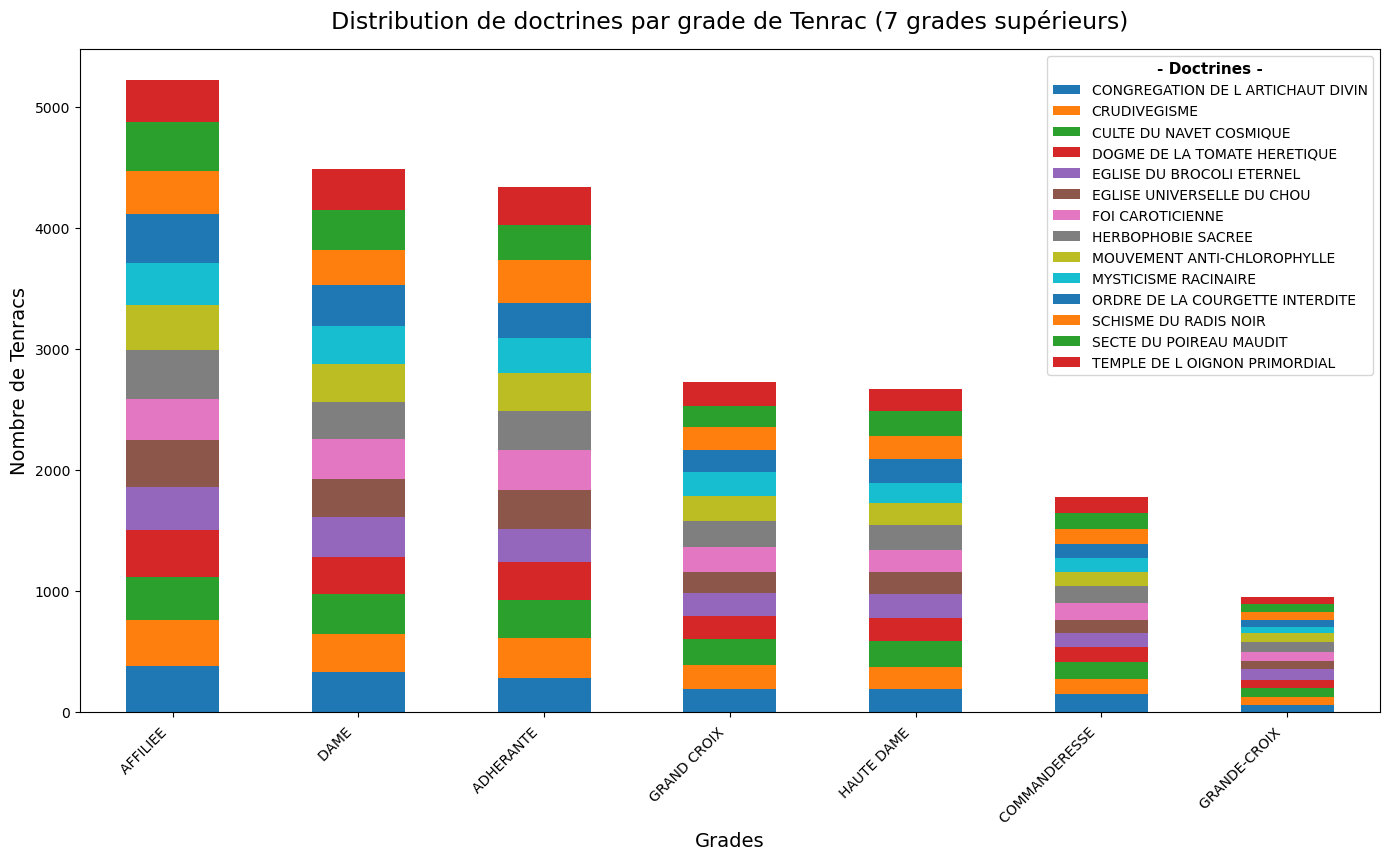

In [27]:
# Diagramme de Distribution de doctrines par grade de Tenrac (7 grades inférieurs)
inf7Grades.plot(kind='bar', stacked=True, figsize=(14,9)) #, ax=plt.gca()
plt.xlabel('Grades', fontsize=14)
plt.ylabel('Nombre de Tenracs', fontsize=14)
plt.title('Distribution de doctrines par grade de Tenrac (7 grades inférieurs)', fontsize=17, pad=15)

# Modifier le format du titre de la légende et le positionner à droite et en haut
legend = plt.legend(title='- Doctrines -', fontsize=10, loc='upper right')
legend.get_title().set_fontsize(11)
legend.get_title().set_fontweight('bold')

plt.tight_layout()

# Incline les grades à 35° alignées à droite
plt.tick_params(axis='x', rotation=45)
plt.xticks(ha='right')
plt.show()

print()

# Diagramme de Distribution de doctrines par grade de Tenrac (7 grades supérieurs)
sup7Grades.plot(kind='bar', stacked=True, figsize=(14,9)) #, ax=plt.gca()
plt.xlabel('Grades', fontsize=14)
plt.ylabel('Nombre de Tenracs', fontsize=14)
plt.title('Distribution de doctrines par grade de Tenrac (7 grades supérieurs)', fontsize=17, pad=15)

# Modifier le format du titre de la légende et le positionner à droite et en haut
legend = plt.legend(title='- Doctrines -', fontsize=10, loc='upper right')
legend.get_title().set_fontsize(11)
legend.get_title().set_fontweight('bold')

plt.tight_layout()

# Incline les grades à 35° alignées à droite
plt.tick_params(axis='x', rotation=45)
plt.xticks(ha='right')
plt.show()


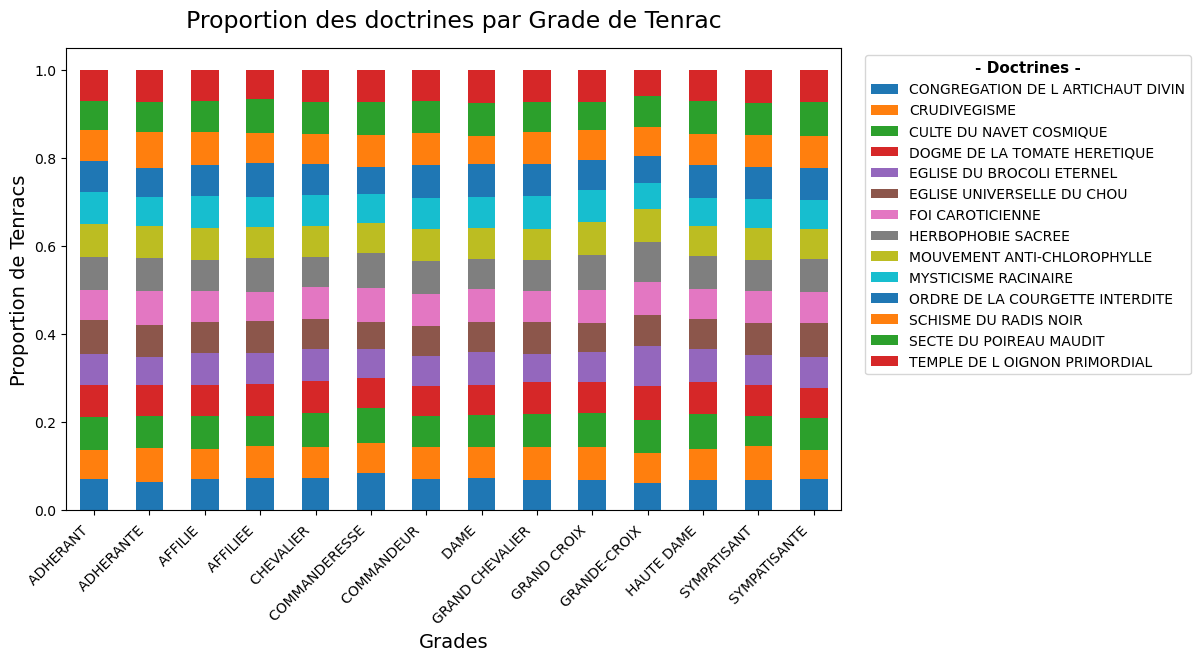

In [23]:
countDoctrinesProportion = countDoctrines.div(countDoctrines.sum(axis=1), axis=0)

countDoctrinesProportion.plot(kind='bar', stacked=True, figsize=(10,6))
plt.xlabel('Grades', fontsize=14)
plt.ylabel('Proportion de Tenracs', fontsize=14)
plt.title('Proportion des doctrines par Grade de Tenrac', fontsize=17, pad=15)

# Modifier le format du titre de la légende et le positionner à l'extérieur, à droite et en haut
legend = plt.legend(title='- Doctrines -', fontsize=10, bbox_to_anchor=(1.46, 1),loc='upper right')
legend.get_title().set_fontsize(11)
legend.get_title().set_fontweight('bold')

# Incline les grades à 35° alignées à droite
plt.tick_params(axis='x', rotation=45)
plt.xticks(ha='right')

plt.show()

In [ ]:
'''
graphes on tope of each other
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12,12))

top7Grades.plot(kind='bar', stacked=True, ax=axes[0])
axes[0].set_title('Top 7 grades')

bottom7Grades.plot(kind='bar', stacked=True, ax=axes[1])
axes[1].set_title('Bottom 7 grades')

plt.tight_layout()
plt.show()
'''

In [ ]:
# Correlation entre being Grade x and being croyant y...?



In [ ]:
# does it worth it to calcla droite de regresion lineaire??
# diagram about this...

In [29]:

#OTHER ? amount of reunions over time  ??